# `hsic_parents` — does the choice of HSIC parents change identifiability?

Auto-discovers every finished run under
`experiments/tests/hsic_parents/results/<arm>_<jobid>/` and overlays
their training-time metrics + final structural / reconstruction summaries.

**The four arms** (see `experiments/tests/hsic_parents/README.md` for theory):

| Arm | Hard mask | `λ_hsic_cross` | `λ_hsic_self` | Role |
|---|---|---|---|---|
| `e1_self_only_hsic`              | learned | **0.0** | **1.0** | proposal: drop S from HSIC |
| `e2_ref_joint_hsic`              | learned | 1.0 | 1.0 | reference (current code) |
| `oracle`                         | GT      | 0.0 | 0.0 | recon ceiling |
| `anti_oracle_preserve_sparsity`  | corrupt(preserve_sparsity) | 0.0 | 0.0 | recon floor at matched density |

**Decision rule** (short form). For the *learned-attention* arms compare:

- `cross-SHD(e1) ≤ cross-SHD(e2)` AND `val_x_r2(e1) ≳ val_x_r2(e2)` ⇒ proposal supported.
- `e1 ≈ e2` ⇒ no tug-of-war effect at this scale.
- `e1` near the anti-oracle metrics ⇒ structural signal collapsed without cross-HSIC.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread

RESULTS_DIR = Path("../experiments/tests/hsic_parents/results").resolve()
assert RESULTS_DIR.exists(), f"Results dir not found: {RESULTS_DIR}"

# Window (in epochs) over which converged-value summaries are computed.
CONVERGED_WINDOW = 50

# Stable color per logical experiment label so re-runs / new runs keep colours.
_PALETTE = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_LABEL_COLORS: dict[str, str] = {}

def color_for(label: str) -> str:
    if label not in _LABEL_COLORS:
        _LABEL_COLORS[label] = _PALETTE[len(_LABEL_COLORS) % len(_PALETTE)]
    return _LABEL_COLORS[label]

## Discovery

Scan the results directory, parse `metrics.csv` (training trajectory),
`kfold_summary.json` (final scalars), and `dag_metrics.json` (structural
metrics). Anything missing is filed as `NaN` and the run is still listed.
Runs are matched by stripping the trailing `_<jobid>` from the folder name.

In [2]:
_JOBID_RE = re.compile(r"_(\d{5,})$")

def _strip_jobid(folder_name: str) -> str:
    return _JOBID_RE.sub("", folder_name)

def _latest_metrics_csv(run_dir: Path) -> Path | None:
    csv_root = run_dir / "k_0" / "logs" / "csv"
    if not csv_root.exists():
        return None
    versions = sorted(
        (p for p in csv_root.glob("version_*") if p.is_dir()),
        key=lambda p: int(p.name.split("_")[-1]) if p.name.split("_")[-1].isdigit() else -1,
    )
    for v in reversed(versions):
        m = v / "metrics.csv"
        if m.exists():
            return m
    return None

def _read_run(run_dir: Path) -> dict | None:
    csv_path = _latest_metrics_csv(run_dir)
    if csv_path is None:
        return None
    raw = pd.read_csv(csv_path)
    if "epoch" not in raw.columns:
        return None
    df = raw.groupby("epoch", as_index=False).first().sort_values("epoch").reset_index(drop=True)

    # Sum cross + self HSIC (same scale within a hsic_mode group).
    for sfx in ("train", "val"):
        cs, ss = f"{sfx}_hsic_cross", f"{sfx}_hsic_self"
        if cs in df.columns and ss in df.columns:
            df[f"{sfx}_hsic_sum"] = df[cs] + df[ss]

    cfg = {}
    cfg_path = run_dir / "config_single_causal_svfa.yaml"
    if cfg_path.exists():
        with open(cfg_path) as fh:
            cfg = yaml.safe_load(fh) or {}
    training = cfg.get("training", {}) or {}
    experiment = cfg.get("experiment", {}) or {}

    # kfold_summary scalars (validation + test).
    kfs = {}
    kfs_path = run_dir / "kfold_summary.json"
    if kfs_path.exists():
        with open(kfs_path) as fh:
            kfs = json.load(fh) or {}
    fold0 = ((kfs.get("fold_results") or {}).get("0") or {}).get("metrics", {}) or {}

    # Structural metrics (post-train DAG comparison).
    dag = {}
    dag_path = run_dir / "eval" / "eval_attention_scores" / "files" / "dag_metrics.json"
    if dag_path.exists():
        with open(dag_path) as fh:
            dag = json.load(fh) or {}

    # DAG-comparison figure (rendered by the eval pipeline) for inline display.
    dag_fig = None
    fig_dir = run_dir / "eval" / "eval_attention_scores" / "fig"
    if fig_dir.exists():
        cands = sorted(fig_dir.glob("dag_comparison_*.png"))
        if cands:
            dag_fig = cands[0]

    label = _strip_jobid(run_dir.name)
    meta = {
        "folder": run_dir.name,
        "label": label,
        "hsic_mode": training.get("hsic_mode"),
        "hsic_kernel_source": training.get("hsic_kernel_source"),
        "hsic_adaptive_bandwidth": training.get("hsic_adaptive_bandwidth"),
        "lambda_hsic_cross": training.get("lambda_hsic_cross"),
        "lambda_hsic_self": training.get("lambda_hsic_self"),
        "use_oracle": training.get("use_oracle_attention"),
        "corruption_seed": training.get("hard_masks_corruption_seed"),
        "cross_control_shd": training.get("cross_control_shd"),
        "self_control_shd": training.get("self_control_shd"),
        "preserve_sparsity": training.get("hard_masks_preserve_sparsity"),
        "batch_size": experiment.get("batch_size", training.get("batch_size")),
        "d_model": experiment.get("d_model_set"),
        "max_epochs": experiment.get("max_epochs"),
        "csv_path": str(csv_path),
        "dag_fig": str(dag_fig) if dag_fig is not None else None,
    }
    return {"df": df, "meta": meta, "fold0": fold0, "dag": dag}

runs: dict[str, dict] = {}
for run_dir in sorted(RESULTS_DIR.iterdir()):
    if not run_dir.is_dir():
        continue
    item = _read_run(run_dir)
    if item is None:
        continue
    runs[item["meta"]["label"]] = item

# Force a deterministic plot order: oracle (floor), e1 (proposal), e2 (reference), anti_oracle (ceiling).
_ORDER_HINT = ["oracle", "e1_self_only_hsic", "e2_ref_joint_hsic", "anti_oracle_preserve_sparsity"]
_order_key = lambda lbl: (_ORDER_HINT.index(lbl) if lbl in _ORDER_HINT else len(_ORDER_HINT), lbl)
runs = {k: runs[k] for k in sorted(runs.keys(), key=_order_key)}

summary = pd.DataFrame(
    [
        {
            "label": item["meta"]["label"],
            "folder": item["meta"]["folder"],
            "epochs_logged": int(item["df"]["epoch"].max() + 1),
            "λ_hsic_cross": item["meta"]["lambda_hsic_cross"],
            "λ_hsic_self": item["meta"]["lambda_hsic_self"],
            "oracle": item["meta"]["use_oracle"],
            "corr_seed": item["meta"]["corruption_seed"],
            "preserve_sparsity": item["meta"]["preserve_sparsity"],
            "hsic_mode": item["meta"]["hsic_mode"],
        }
        for item in runs.values()
    ]
).set_index("label")
print(f"Discovered {len(runs)} runs under {RESULTS_DIR}")
summary

Discovered 5 runs under C:\Users\ScipioneFrancesco\Documents\Projects\causaliT\experiments\tests\hsic_parents\results


,folder,epochs_logged,λ_hsic_cross,λ_hsic_self,oracle,corr_seed,preserve_sparsity,hsic_mode
label,,,,,,,,
oracle,oracle_64894237,501,0.0,0.0,True,NaN,False,biased
e1_self_only_hsic,e1_self_only_hsic_64894415,501,0.0,1.0,False,NaN,False,biased
e2_ref_joint_hsic,e2_ref_joint_hsic_64894263,501,1.0,1.0,False,NaN,False,biased
anti_oracle_preserve_sparsity,anti_oracle_preserve_sparsity_64894437,501,0.0,0.0,True,42.0,False,biased
e1_self_only_hsic_sigmoidcross,e1_self_only_hsic_sigmoidcross_64958569,501,0.0,1.0,False,NaN,False,biased


In [3]:
def legend_label(meta: dict) -> str:
    bits = [meta["label"]]
    lc, ls = meta.get("lambda_hsic_cross"), meta.get("lambda_hsic_self")
    if lc is not None or ls is not None:
        bits.append(f"λc={lc} / λs={ls}")
    if meta.get("use_oracle"):
        bits.append("oracle")
    if meta.get("corruption_seed") not in (None, 0):
        bits.append(f"corr=s{meta['corruption_seed']}"
                    + (" preserve" if meta.get("preserve_sparsity") else ""))
    return "  |  ".join(bits)

def plot_metric(ax, metric: str, runs_dict: dict | None = None, *,
                ylabel: str | None = None, logy: bool = False) -> None:
    if runs_dict is None:
        runs_dict = runs
    plotted = 0
    for item in runs_dict.values():
        df = item["df"]
        if metric not in df.columns:
            continue
        s = df[["epoch", metric]].dropna()
        if s.empty:
            continue
        ax.plot(
            s["epoch"], s[metric],
            color=color_for(item["meta"]["label"]),
            label=legend_label(item["meta"]),
            linewidth=1.6,
        )
        plotted += 1
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    if logy:
        ax.set_yscale("log")
    if plotted == 0:
        ax.text(0.5, 0.5, f"no '{metric}' logged", ha="center", va="center",
                transform=ax.transAxes, alpha=0.5)

## 1 · HSIC curves (validation, training)

**Reading the panels:**

- `oracle` is the achievable noise-floor for both `val_hsic_cross` and `val_hsic_self`.
- `anti_oracle_preserve_sparsity` is the ceiling reachable by a wrong DAG of matched density.
- `e1` (proposal) and `e2` (reference) should sit between these two boundaries.
- For `e1` we expect `val_hsic_cross` to *not* descend (since `λ_hsic_cross = 0` —
  it is logged but not optimised). For `e2` it should descend to the floor.

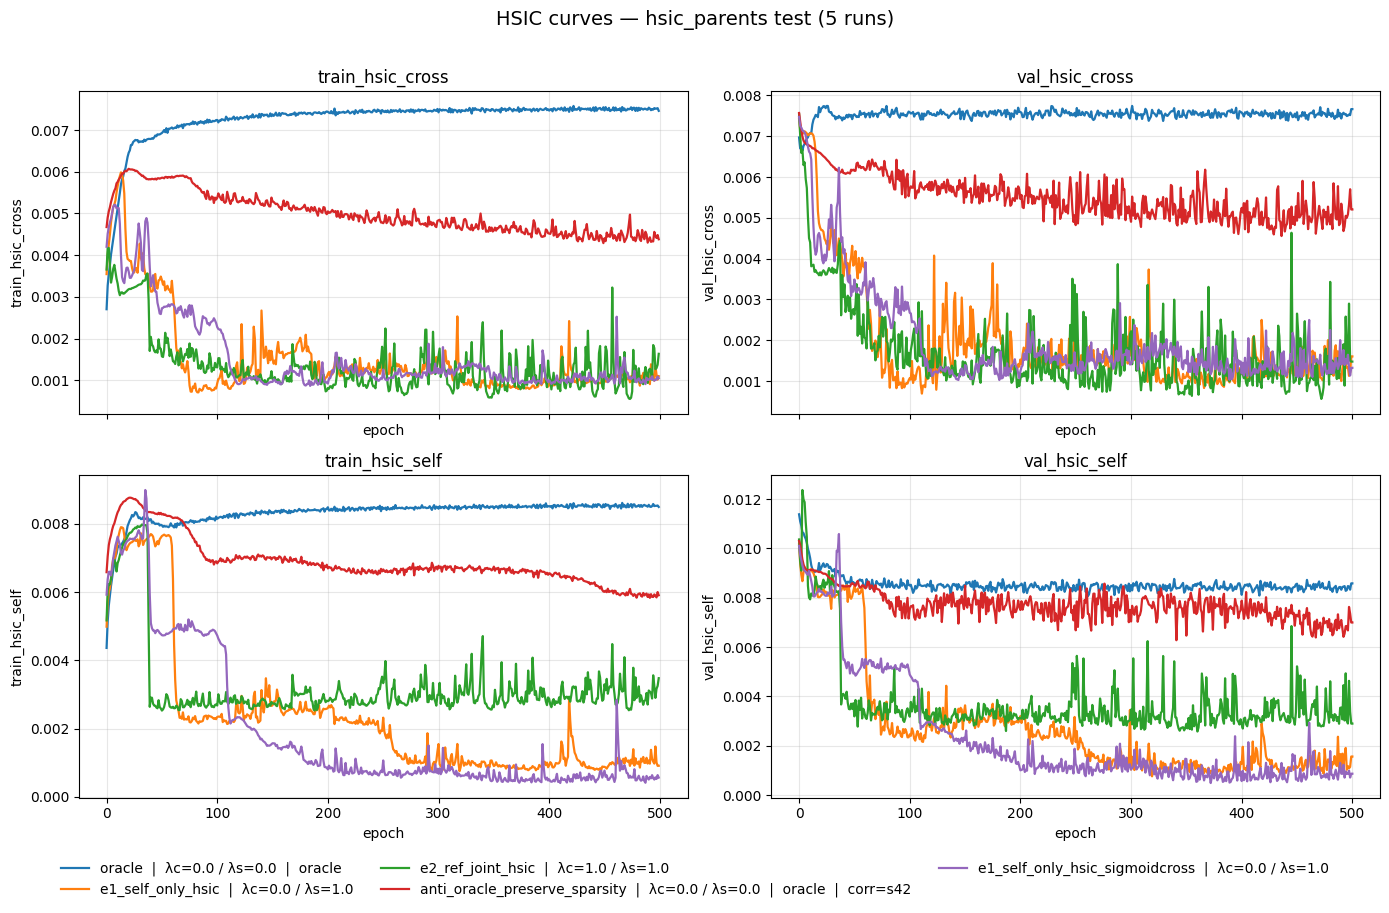

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plot_metric(axes[0, 0], "train_hsic_cross")
plot_metric(axes[0, 1], "val_hsic_cross")
plot_metric(axes[1, 0], "train_hsic_self")
plot_metric(axes[1, 1], "val_hsic_self")
handles, labels = axes[0, 0].get_legend_handles_labels()
if not handles:
    for ax in axes.ravel():
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
fig.suptitle(f"HSIC curves — hsic_parents test ({len(runs)} runs)", fontsize=14)
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=min(3, max(1, len(runs))), frameon=False)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
plt.show()

## 2 · Reconstruction quality

Same data, same backbone — only the *attention alignment* differs (or, for the
learned arms, the structural objective). Worse `val_x_rmse` / lower `val_x_r2`
indicate that the structural pathway is feeding bad routing to the predictor.

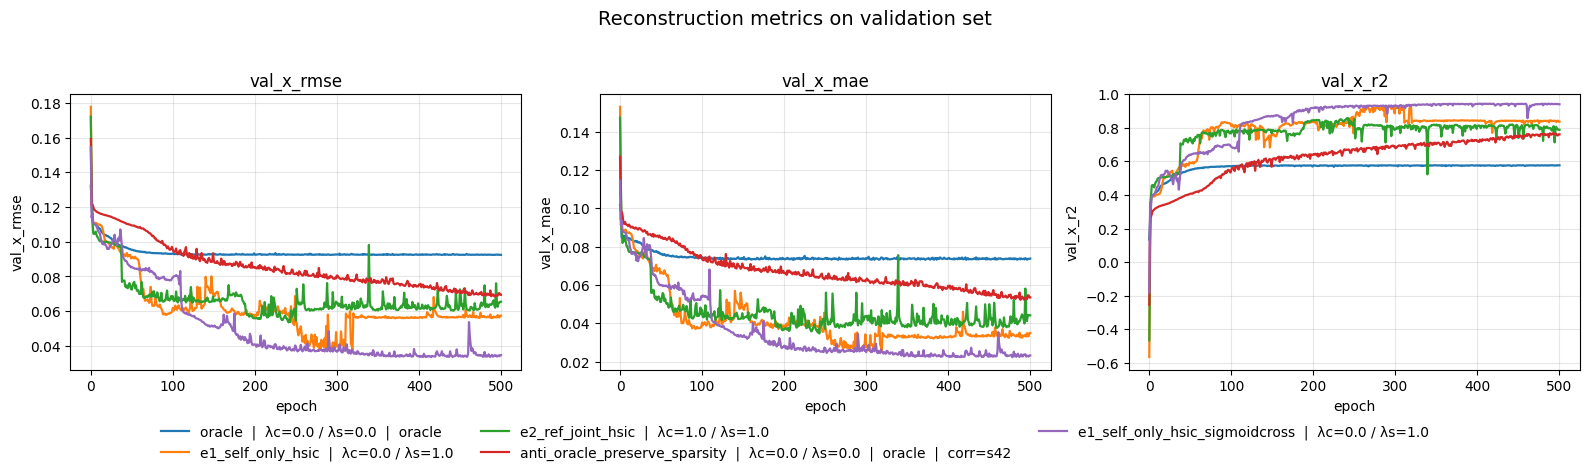

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
plot_metric(axes[0], "val_x_rmse")
plot_metric(axes[1], "val_x_mae")
plot_metric(axes[2], "val_x_r2")
axes[2].set_ylim(top=1.0)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=min(3, max(1, len(runs))), frameon=False)
fig.suptitle("Reconstruction metrics on validation set", fontsize=14)
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

## 3 · Routed loss decomposition (sanity)

For oracle / anti-oracle every structural λ is `0.0`, so
`train_loss_structural_routed` should sit at zero. For `e1` only the self-HSIC
term contributes; for `e2` both.

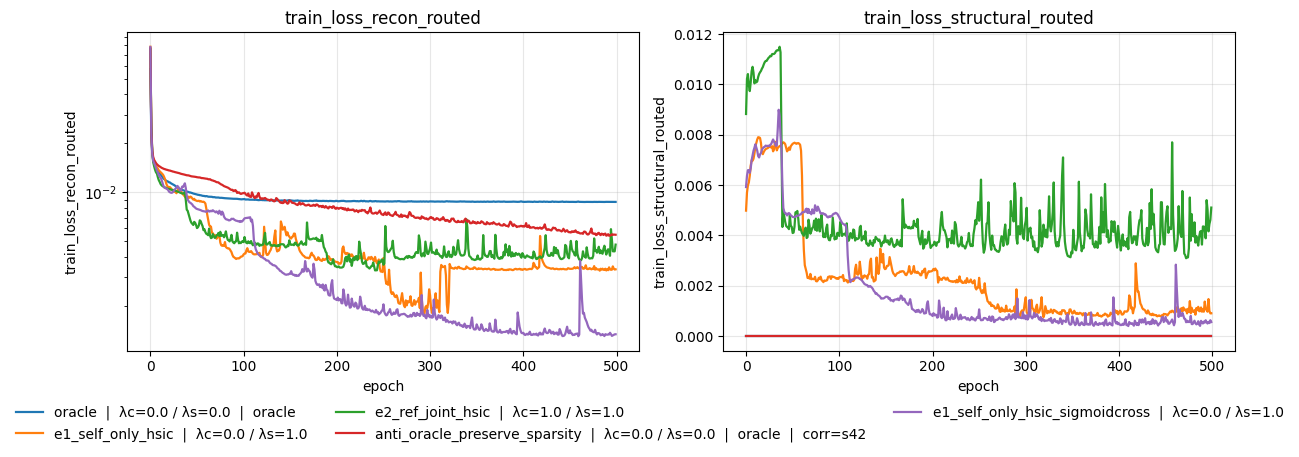

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
plot_metric(axes[0], "train_loss_recon_routed", logy=True)
plot_metric(axes[1], "train_loss_structural_routed")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=min(3, max(1, len(runs))), frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

## 4 · Converged values — last 50 epochs

Mean over the final `CONVERGED_WINDOW` epochs of each run. This is the
at-a-glance comparison: any learned-arm value should sit in the
[`oracle`, `anti_oracle_preserve_sparsity`] envelope.

,val_hsic_cross,val_hsic_self,val_hsic_sum,val_x_rmse,val_x_mae,val_x_r2
label,,,,,,
oracle,0.0075,0.0084,0.0160,0.0925,0.0736,0.5761
e1_self_only_hsic,0.0014,0.0013,0.0027,0.0570,0.0339,0.8393
e2_ref_joint_hsic,0.0014,0.0034,0.0049,0.0637,0.0418,0.7984
anti_oracle_preserve_sparsity,0.0051,0.0069,0.0120,0.0700,0.0540,0.7572
e1_self_only_hsic_sigmoidcross,0.0014,0.0010,0.0024,0.0354,0.0238,0.9376


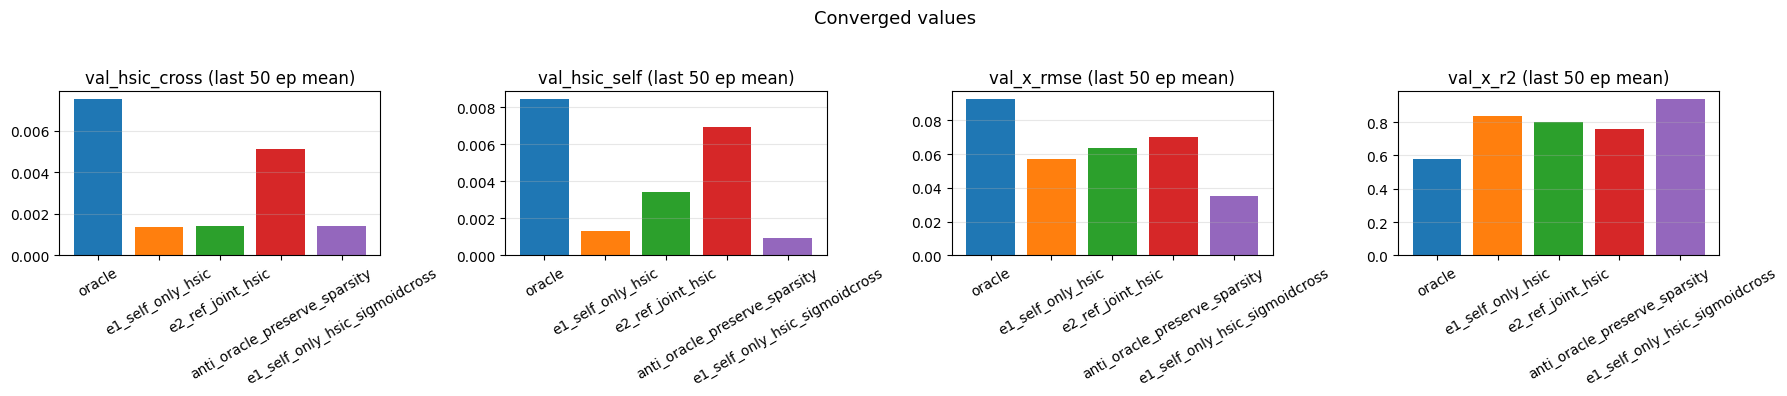

In [7]:
_CONV_METRICS = [
    "val_hsic_cross", "val_hsic_self", "val_hsic_sum",
    "val_x_rmse", "val_x_mae", "val_x_r2",
]
_BAR_METRICS = ["val_hsic_cross", "val_hsic_self", "val_x_rmse", "val_x_r2"]

def _converged_table(runs_dict: dict) -> pd.DataFrame:
    rows = []
    for label, item in runs_dict.items():
        df = item["df"]
        last_epochs = df.tail(CONVERGED_WINDOW)
        row = {"label": label}
        for m in _CONV_METRICS:
            row[m] = float(last_epochs[m].mean(skipna=True)) if m in last_epochs.columns else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("label") if rows else pd.DataFrame(columns=_CONV_METRICS)

conv = _converged_table(runs)
display(conv.style.format("{:.4f}"))

fig, axes = plt.subplots(1, len(_BAR_METRICS), figsize=(4.5 * len(_BAR_METRICS), 4))
for ax, m in zip(axes, _BAR_METRICS):
    series = conv[m].dropna() if m in conv.columns else pd.Series(dtype=float)
    if series.empty:
        ax.text(0.5, 0.5, f"no '{m}' logged", ha="center", va="center",
                transform=ax.transAxes, alpha=0.5)
    else:
        colors = [color_for(lbl) for lbl in series.index]
        ax.bar(series.index, series.values, color=colors)
    ax.set_title(f"{m} (last {CONVERGED_WINDOW} ep mean)")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Converged values", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## 5 · Structural metrics (post-train DAG vs ground truth)

From `eval/eval_attention_scores/files/dag_metrics.json`. The headline numbers
for the proposal vs reference comparison are:

- **`soft_hamming_cross`** — soft Hamming distance between learned cross-attention
  scores and the ground-truth cross mask. Continuous, no threshold.
- **`standard_shd_cross`** — thresholded SHD with breakdown into
  *missing*, *extra*, *reversed* edges.
- **`soft_hamming_self`** / **`standard_shd_self`** — same for the self-attention DAG.
- **`mec_distance`** — distance to the Markov-equivalence class of the truth
  (1 means *in* the MEC, ≥0 otherwise; the `in_mec` flag is also logged).

Oracle / anti-oracle are degenerate here (the mask **is** the GT or the
corrupted GT), so their numbers serve as the trivial bookends — `oracle` should
be ≈ 0 on every Hamming/SHD; `anti_oracle` should be at the maximum reachable.

In [8]:
def _struct_row(label: str, dag: dict) -> dict:
    def _mean(d, k):
        v = (d.get(k) or {}).get("mean")
        return float(v) if v is not None else np.nan
    mec = (dag.get("mec_distance") or {}).get("per_fold", {}).get("k_0", {})
    shd_x = (dag.get("standard_shd_cross") or {}).get("per_fold_details", {}).get("k_0", {})
    shd_s = (dag.get("standard_shd_self") or {}).get("per_fold_details", {}).get("k_0", {})
    return {
        "label": label,
        "soft_H_cross": _mean(dag, "soft_hamming_cross"),
        "SHD_cross": _mean(dag, "standard_shd_cross"),
        "missing_cross": shd_x.get("missing"),
        "extra_cross": shd_x.get("extra"),
        "reversed_cross": shd_x.get("reversed"),
        "n_pred_cross": shd_x.get("n_pred_edges"),
        "n_true_cross": shd_x.get("n_true_edges"),
        "soft_H_self": _mean(dag, "soft_hamming_self"),
        "SHD_self": _mean(dag, "standard_shd_self"),
        "missing_self": shd_s.get("missing"),
        "extra_self": shd_s.get("extra"),
        "reversed_self": shd_s.get("reversed"),
        "n_pred_self": shd_s.get("n_pred_edges"),
        "n_true_self": shd_s.get("n_true_edges"),
        "mec_distance": _mean(dag, "mec_distance"),
        "in_mec": mec.get("in_mec"),
        "skel_recall": mec.get("skeleton_recall"),
        "skel_precision": mec.get("skeleton_precision"),
    }

struct = pd.DataFrame(
    [_struct_row(lbl, item["dag"]) for lbl, item in runs.items()]
).set_index("label")
display(struct.style.format(precision=4, na_rep="—"))

,soft_H_cross,SHD_cross,missing_cross,extra_cross,reversed_cross,n_pred_cross,n_true_cross,soft_H_self,SHD_self,missing_self,extra_self,reversed_self,n_pred_self,n_true_self,mec_distance,in_mec,skel_recall,skel_precision
label,,,,,,,,,,,,,,,,,,
oracle,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000,5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,3.0000,0.0000,True,1.0000,1.0000
e1_self_only_hsic,0.1766,4.0000,4.0000,0.0000,0.0000,1.0000,5.0000,0.1341,2.0000,0.0000,2.0000,0.0000,5.0000,3.0000,0.5936,False,0.4086,0.9278
e2_ref_joint_hsic,0.2009,5.0000,5.0000,0.0000,0.0000,0.0000,5.0000,0.2568,6.0000,3.0000,2.0000,1.0000,2.0000,3.0000,0.8454,False,0.1848,0.9466
anti_oracle_preserve_sparsity,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
e1_self_only_hsic_sigmoidcross,0.1699,4.0000,4.0000,0.0000,0.0000,1.0000,5.0000,0.1560,5.0000,2.0000,2.0000,1.0000,3.0000,3.0000,0.7502,False,0.3286,0.9566


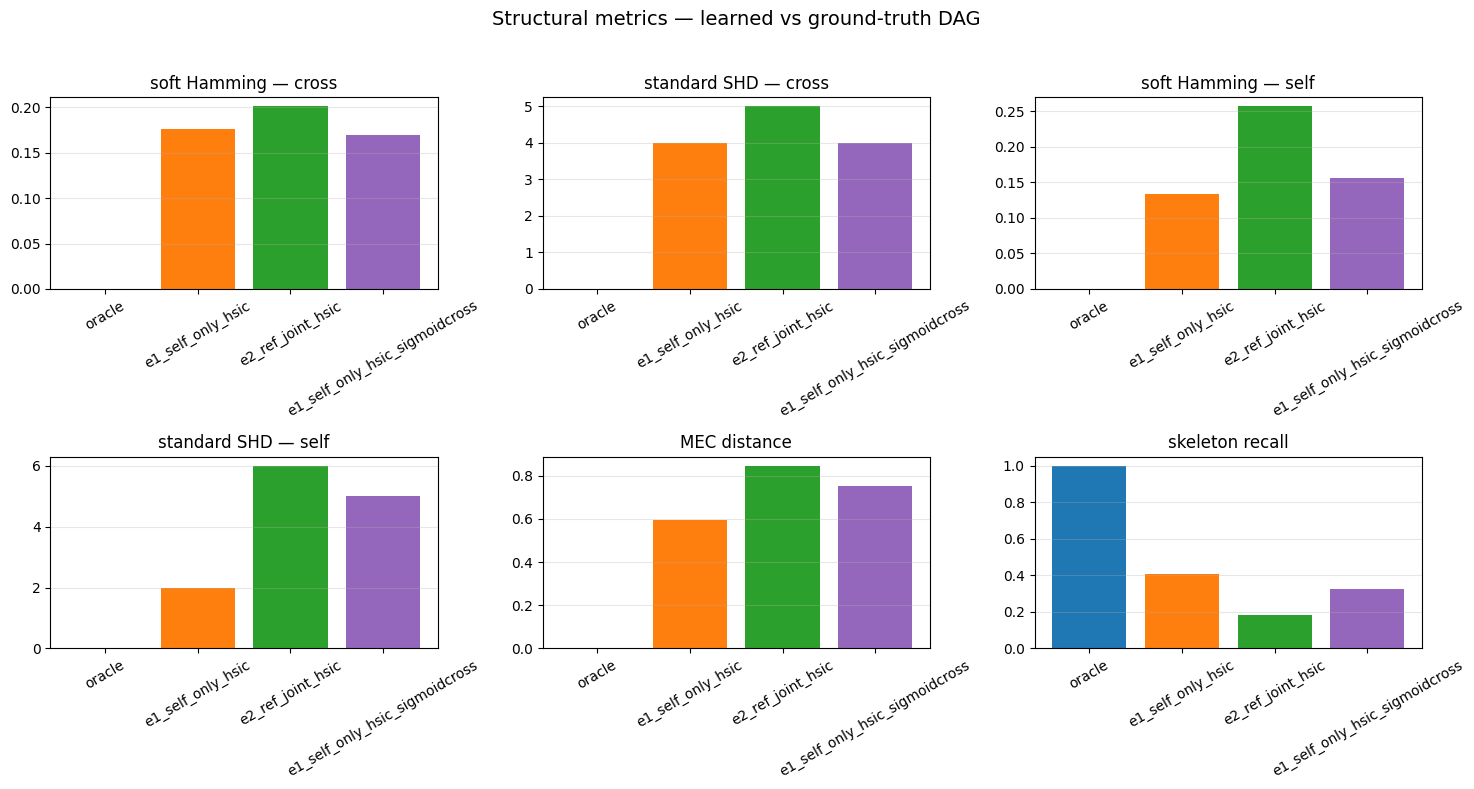

In [9]:
_STRUCT_BARS = [
    ("soft_H_cross",  "soft Hamming — cross"),
    ("SHD_cross",     "standard SHD — cross"),
    ("soft_H_self",   "soft Hamming — self"),
    ("SHD_self",      "standard SHD — self"),
    ("mec_distance",  "MEC distance"),
    ("skel_recall",   "skeleton recall"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, title) in zip(axes.ravel(), _STRUCT_BARS):
    if col not in struct.columns:
        ax.text(0.5, 0.5, f"no '{col}'", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
        continue
    series = struct[col].dropna()
    if series.empty:
        ax.text(0.5, 0.5, f"no data for '{col}'", ha="center", va="center",
                transform=ax.transAxes, alpha=0.5)
        ax.set_title(title)
        continue
    colors = [color_for(lbl) for lbl in series.index]
    ax.bar(series.index, series.values, color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Structural metrics — learned vs ground-truth DAG", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

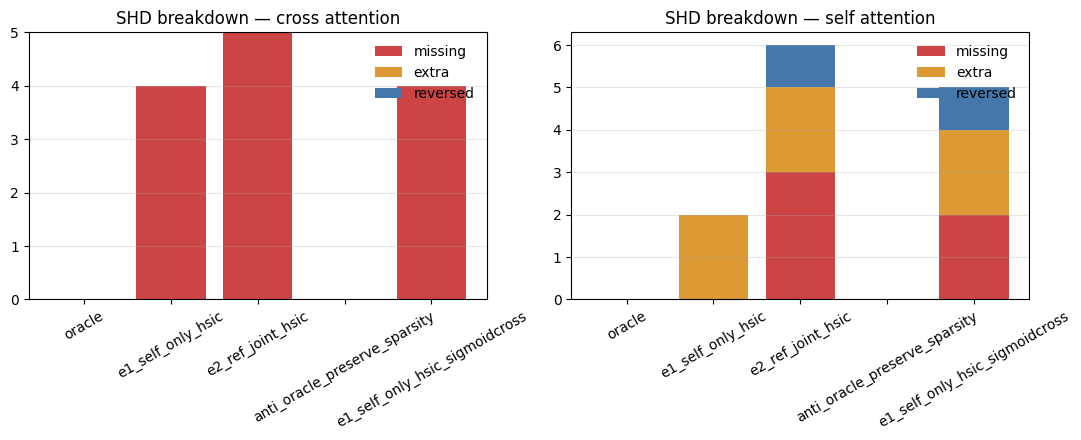

In [10]:
# Stacked-bar breakdown of SHD into missing / extra / reversed.
def _stacked_shd(ax, prefix: str, title: str) -> None:
    cats = [f"missing_{prefix}", f"extra_{prefix}", f"reversed_{prefix}"]
    sub = struct[cats].fillna(0).astype(float)
    if sub.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
        return
    bottom = np.zeros(len(sub))
    for cat, color in zip(cats, ["#cc4444", "#dd9933", "#4477aa"]):
        ax.bar(sub.index, sub[cat].values, bottom=bottom, color=color, label=cat.split("_")[0])
        bottom = bottom + sub[cat].values
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="upper right", frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
_stacked_shd(axes[0], "cross", "SHD breakdown — cross attention")
_stacked_shd(axes[1], "self",  "SHD breakdown — self attention")
fig.tight_layout()
plt.show()

## 6 · Pre-rendered DAG comparison figures

The eval pipeline renders one `dag_comparison_*.png` per run (learned scores
vs ground-truth masks). Inline them here so all four arms are on one page.

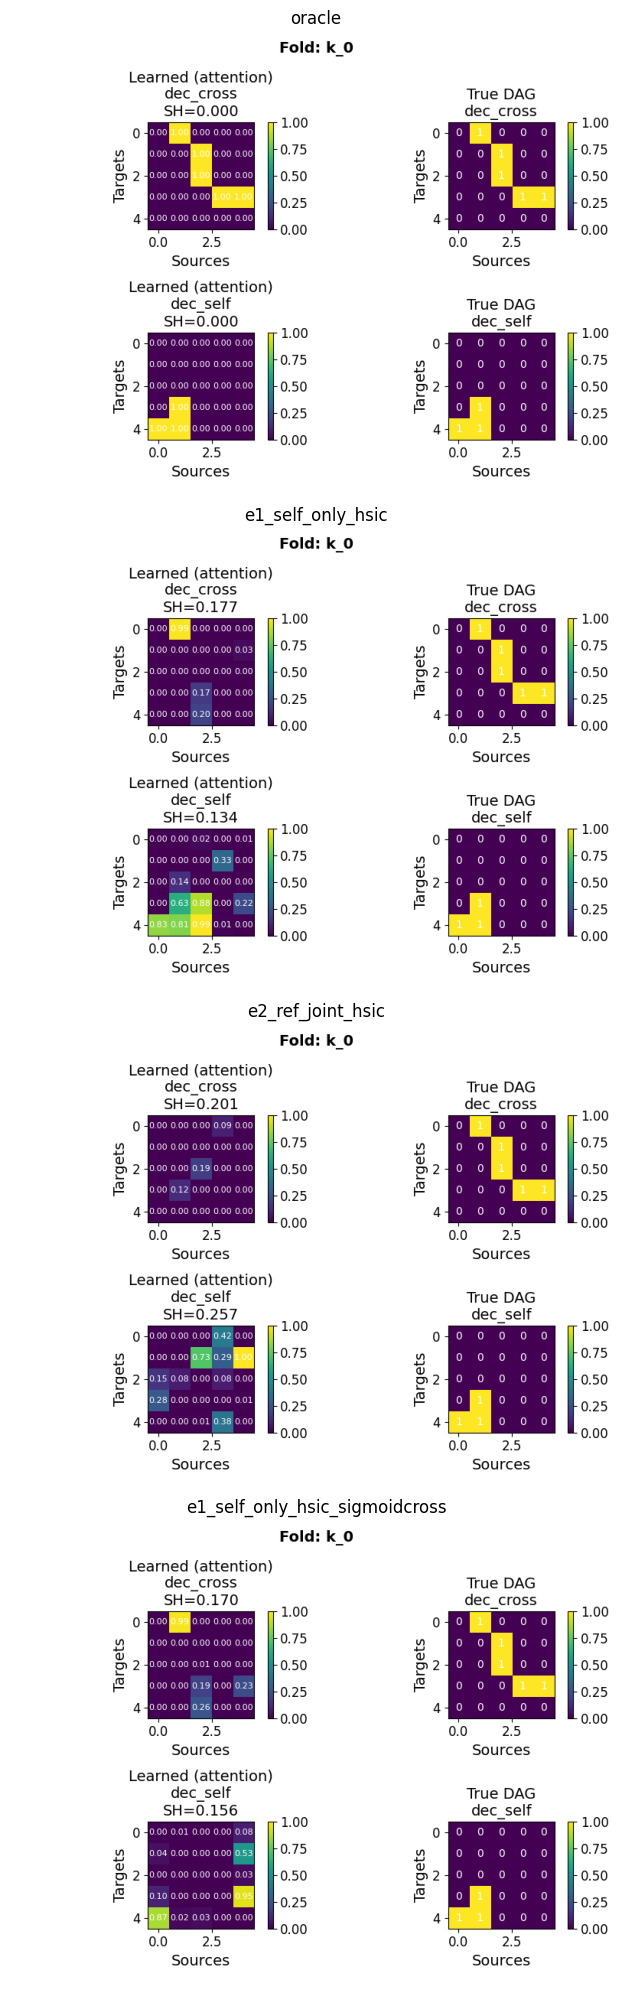

In [11]:
_with_fig = [(lbl, item) for lbl, item in runs.items() if item["meta"].get("dag_fig")]
if not _with_fig:
    print("No dag_comparison_*.png figures found.")
else:
    n = len(_with_fig)
    fig, axes = plt.subplots(n, 1, figsize=(11, 5 * n))
    if n == 1:
        axes = [axes]
    for ax, (lbl, item) in zip(axes, _with_fig):
        img = imread(item["meta"]["dag_fig"])
        ax.imshow(img)
        ax.set_title(lbl, fontsize=12)
        ax.axis("off")
    fig.tight_layout()
    plt.show()

## Reading the results — decision flowchart

Comparing the **learned-attention** arms `e1_self_only_hsic` and `e2_ref_joint_hsic`:

1. **`SHD_cross(e1) ≤ SHD_cross(e2)` AND `val_x_r2(e1) ≳ val_x_r2(e2)`**
   ⇒ proposal supported. Drop S from HSIC; add L1 on cross in iter-8.
2. **`SHD_cross(e1) ≈ SHD_cross(e2)` AND `val_x_r2` similar**
   ⇒ no tug-of-war effect at this scale; cross-HSIC is neither helpful nor harmful.
3. **`SHD_cross(e1) ≫ SHD_cross(e2)` (worse)**
   ⇒ cross-HSIC was load-bearing for cross identification. Revert.
4. **`val_hsic_self(e1) ≈ val_hsic_self(anti_oracle)`** (or recon collapse)
   ⇒ catastrophic; structural signal collapsed without cross-HSIC.

Note the boundaries:

- `oracle` is the achievable best for `val_x_r2` and the floor for `val_hsic_*`.
- `anti_oracle_preserve_sparsity` is the matched-density wrong-DAG bound. If `e1`
  or `e2` lie near it, structure has not been learned at all.